# 순환 신경망 기반 3-class 감성 분석 (긍정/중립/부정)
**`web_crawling` 폴더의 모든 CSV를 학습/예측에 활용** — 학습 데이터 약 **30만 건**

## 데이터 활용 계획
| 파일 | 건수 | 평점 컬럼 | 용도 |
|---|---|---|---|
| `yes24_book_reviews.csv` | 42,890 | `ReviewRating` (1~10) | 학습 + 예측 (Korean) |
| `reviews.csv` | 270,414 | `rating` (1~5) | 번역 후 학습 + 예측 (English→Korean) |
| `watcha_book_comments.csv` | 105,185 | 없음 | 예측만 |

**학습 데이터 합계: 313,304건** (평점 있는 것)

## 라벨 규칙
- yes24: 1~4=부정, 5~7=중립, 8~10=긍정
- reviews: 1~2=부정, 3=중립, 4~5=긍정

## 모델
Embedding → Bidirectional LSTM → Dropout → Dense → Dense(3, softmax)

## 필요 라이브러리
```
pip install tensorflow konlpy scikit-learn matplotlib tqdm joblib
pip install transformers torch sentencepiece sacremoses   # 로컬 번역(Helsinki NMT)
```

In [1]:
import os, re, gc
import numpy as np
import pandas as pd
import joblib
from tqdm import tqdm
from konlpy.tag import Okt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

tqdm.pandas()
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

okt = Okt()
LABEL_NAMES = ['부정', '중립', '긍정']  # 0, 1, 2

c:\Users\user\anaconda3\envs\aiservice26\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 1. 학습 데이터 준비

### 1-1. yes24 (Korean) — ReviewRating 기반 3-class 라벨

In [2]:
df_yes24 = pd.read_csv('yes24_book_reviews.csv')
print(f'yes24 원본: {len(df_yes24):,}건')

def yes24_rating_to_label(r):
    if pd.isna(r) or r <= 0: return -1
    r = int(r)
    if r <= 4: return 0   # 부정
    if r <= 7: return 1   # 중립
    return 2              # 긍정

df_yes24['label'] = df_yes24['ReviewRating'].apply(yes24_rating_to_label)
df_yes24_lbl = df_yes24[df_yes24['label'] >= 0][['ReviewText', 'label']].rename(columns={'ReviewText': 'text'})
df_yes24_lbl['source'] = 'yes24'
print('\n▶ yes24 라벨 분포:')
for k, v in df_yes24_lbl['label'].value_counts().sort_index().items():
    print(f'  {LABEL_NAMES[k]}: {v:,}건')

yes24 원본: 42,890건

▶ yes24 라벨 분포:
  부정: 736건
  중립: 2,303건
  긍정: 39,841건


### 1-2. reviews.csv (English) — rating 기반 3-class 라벨
**번역 전**에 라벨 먼저 만들어 두면, 라벨 균형 맞춰 일부만 번역하여 시간 절약 가능.

In [3]:
df_reviews = pd.read_csv('reviews.csv')
print(f'reviews 원본: {len(df_reviews):,}건')

def reviews_rating_to_label(r):
    try: r = float(r)
    except: return -1
    if pd.isna(r): return -1
    if r <= 2: return 0   # 부정 (1, 2)
    if r <= 3: return 1   # 중립 (3)
    if r <= 5: return 2   # 긍정 (4, 5)
    return -1

df_reviews['label'] = df_reviews['rating'].apply(reviews_rating_to_label)
df_reviews_lbl_all = df_reviews[df_reviews['label'] >= 0][['text', 'label']].copy()
df_reviews_lbl_all['source'] = 'reviews'
df_reviews_lbl_all = df_reviews_lbl_all[df_reviews_lbl_all['text'].notna()]
df_reviews_lbl_all = df_reviews_lbl_all[df_reviews_lbl_all['text'].str.strip() != '']
print(f'\nreviews 라벨 분포 (전체):')
for k, v in df_reviews_lbl_all['label'].value_counts().sort_index().items():
    print(f'  {LABEL_NAMES[k]}: {v:,}건')

reviews 원본: 270,414건

reviews 라벨 분포 (전체):
  부정: 72,137건
  중립: 59,707건
  긍정: 134,852건


### 1-3. reviews.csv 번역 (English → Korean)
**Helsinki-NLP NMT** 로컬 모델로 배치 번역 (Google API 보다 훨씬 빠름).

- `MAX_PER_CLASS`: 클래스별 최대 번역 건수
  - 기본 100,000 → 약 27만 전체에서 균형 잡힌 30만 학습세트 구성 (긍정 100k + 중립 60k + 부정 72k)
  - GPU 없으면 시간이 오래 걸리므로 작은 값(예: 10,000)으로 먼저 테스트

In [4]:
MAX_PER_CLASS = 100_000  # 클래스별 최대 번역 건수 (작게 시작해도 OK: 5000~10000)
TRANS_BATCH = 32         # 배치 크기 (GPU 메모리에 맞게 조정)
TRANS_MAX_LEN = 256      # 너무 긴 문장은 잘라서 번역
USE_GPU = True           # GPU 자동 감지

# 클래스별 균형 추출 (각 클래스에서 MAX_PER_CLASS만큼만 뽑아 번역)
df_reviews_sample = (
    df_reviews_lbl_all
    .groupby('label', group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), MAX_PER_CLASS), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)
print('번역 대상 reviews 라벨 분포:')
for k, v in df_reviews_sample['label'].value_counts().sort_index().items():
    print(f'  {LABEL_NAMES[k]}: {v:,}건')
print(f'총 번역 대상: {len(df_reviews_sample):,}건')

번역 대상 reviews 라벨 분포:
  부정: 72,137건
  중립: 59,707건
  긍정: 100,000건
총 번역 대상: 231,844건


C:\Users\user\AppData\Local\Temp\ipykernel_16588\1056754727.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reviews_lbl_all


In [5]:
# Helsinki NMT 로드 (en → ko)
from transformers import pipeline
import torch

device = 0 if (USE_GPU and torch.cuda.is_available()) else -1
print('번역 장치:', 'GPU' if device == 0 else 'CPU')

translator = pipeline(
    'translation',
    model='Helsinki-NLP/opus-mt-tc-big-en-ko',
    device=device,
    max_length=TRANS_MAX_LEN,
)

번역 장치: GPU



Device set to use cuda:0


In [6]:
def truncate(text, max_chars=1500):
    if not isinstance(text, str): return ''
    t = text.strip()
    return t[:max_chars]

en_texts = [truncate(t) for t in df_reviews_sample['text'].tolist()]

ko_texts = []
print(f'▶ {len(en_texts):,}건 번역 중 (batch={TRANS_BATCH}) ...')
for i in tqdm(range(0, len(en_texts), TRANS_BATCH)):
    batch = en_texts[i:i+TRANS_BATCH]
    try:
        out = translator(batch, batch_size=TRANS_BATCH)
        ko_texts.extend([o['translation_text'] for o in out])
    except Exception as e:
        # 배치 단위 실패 시 개별 처리 (한 문장이 너무 길어 OOM 등)
        for t in batch:
            try:
                o = translator(t)[0]['translation_text']
            except Exception:
                o = ''
            ko_texts.append(o)

df_reviews_sample = df_reviews_sample.iloc[:len(ko_texts)].copy()
df_reviews_sample['text_ko'] = ko_texts
df_reviews_sample.to_csv('reviews_translated_cache.csv', index=False, encoding='utf-8-sig')
print(f'\n✅ 번역 완료. 캐시 저장: reviews_translated_cache.csv')

▶ 231,844건 번역 중 (batch=32) ...


  0%|          | 0/7246 [00:00<?, ?it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (534 > 512). Running this sequence through the model will result in indexing errors
Your input_length: 534 is bigger than 0.9 * max_length: 256. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
  0%|          | 10/7246 [01:47<21:23:35, 10.64s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Your input_length: 584 is bigger than 0.9 * max_length: 256. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
100%|██████████| 7246/7246 [23:06:11<00:00, 11.48s/it]



✅ 번역 완료. 캐시 저장: reviews_translated_cache.csv


In [7]:
# GPU 메모리 해제 (학습 단계에서 메모리 확보)
del translator
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

### 1-4. yes24 + 번역된 reviews 통합

In [8]:
df_reviews_for_train = df_reviews_sample[['text_ko', 'label', 'source']].rename(columns={'text_ko': 'text'})

df_train_all = pd.concat([df_yes24_lbl, df_reviews_for_train], ignore_index=True)
df_train_all = df_train_all[df_train_all['text'].notna()]
df_train_all = df_train_all[df_train_all['text'].astype(str).str.strip() != '']
print(f'▶ 통합 학습 데이터: {len(df_train_all):,}건')
print(df_train_all['label'].value_counts().sort_index().rename(
    index={i: n for i, n in enumerate(LABEL_NAMES)}))
print('\nsource 분포:')
print(df_train_all['source'].value_counts())

▶ 통합 학습 데이터: 254,944건
label
부정     67748
중립     57099
긍정    130097
Name: count, dtype: int64

source 분포:
source
reviews    212064
yes24       42880
Name: count, dtype: int64


### 1-5. 전처리 (정제 + 결측/중복 제거 + 형태소 분석)

In [9]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    cleaned = re.sub('[^ 가-힣]+', ' ', text)
    cleaned = re.sub(' +', ' ', cleaned).strip()
    return cleaned

df_train_all['clean'] = df_train_all['text'].apply(clean_text)
df_train_all['clean'] = df_train_all['clean'].replace('', None)
df_train_all.dropna(subset=['clean'], inplace=True)
df_train_all.drop_duplicates(subset=['clean'], inplace=True)
print(f'정제 후: {len(df_train_all):,}건')
print(df_train_all['label'].value_counts().sort_index().rename(
    index={i: n for i, n in enumerate(LABEL_NAMES)}))

정제 후: 213,432건
label
부정     56150
중립     47071
긍정    110211
Name: count, dtype: int64


In [10]:
print('▶ Okt 형태소 분석 중... (30만 건이면 시간이 좀 걸립니다)')
df_train_all['tokens'] = df_train_all['clean'].progress_apply(okt.morphs)
df_train_all['tokens_str'] = df_train_all['tokens'].apply(lambda x: ' '.join(x))

# 캐시 저장 (시간 오래 걸리는 형태소 분석 결과 보관)
df_train_all[['tokens_str', 'label', 'source']].to_csv('train_tokenized_cache.csv',
                                                       index=False, encoding='utf-8-sig')
print('✅ 캐시 저장: train_tokenized_cache.csv')
df_train_all.head(3)

▶ Okt 형태소 분석 중... (30만 건이면 시간이 좀 걸립니다)


100%|██████████| 213432/213432 [19:20<00:00, 183.87it/s]


✅ 캐시 저장: train_tokenized_cache.csv


,text,label,source,clean,tokens,tokens_str
0,주인공은 컴퓨터의 귀찮은 질문과 함께 깨어난다. 2 더하기 2나 8의 세제곱근 따위...,2,yes24,주인공은 컴퓨터의 귀찮은 질문과 함께 깨어난다 더하기 나 의 세제곱근 따위의 질문을...,"[주인공, 은, 컴퓨터, 의, 귀찮은, 질문, 과, 함께, 깨어난다, 더하기, 나,...",주인공 은 컴퓨터 의 귀찮은 질문 과 함께 깨어난다 더하기 나 의 세제곱근 따위 의...
1,너랑 나는 좋은 사람. p.506 벽돌책과 SF 또는 판타지를 기반으로 한 무언가는...,2,yes24,너랑 나는 좋은 사람 벽돌책과 또는 판타지를 기반으로 한 무언가는 나와 늘 상극이다...,"[너, 랑, 나, 는, 좋은, 사람, 벽돌, 책, 과, 또는, 판타지, 를, 기반,...",너 랑 나 는 좋은 사람 벽돌 책 과 또는 판타지 를 기반 으로 한 무언가 는 나와...
2,물리학에 대한 지식이 조금만 더 있었더라면 하는 아쉬움이 들지만 그럼에도 기본적인 ...,2,yes24,물리학에 대한 지식이 조금만 더 있었더라면 하는 아쉬움이 들지만 그럼에도 기본적인 ...,"[물리학, 에, 대한, 지식, 이, 조금, 만, 더, 있었더라면, 하는, 아쉬움, ...",물리학 에 대한 지식 이 조금 만 더 있었더라면 하는 아쉬움 이 들지만 그럼에도 기...


### 1-6. 학습/테스트 분리

In [11]:
X_text = df_train_all['tokens_str'].tolist()
y_label = df_train_all['label'].tolist()

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_label, test_size=0.1, stratify=y_label, random_state=RANDOM_STATE
)
print(f'학습: {len(X_train_text):,}건, 테스트: {len(X_test_text):,}건')

학습: 192,088건, 테스트: 21,344건


### 1-7. Tokenizer + Integer Encoding + Padding

In [12]:
VOCAB_SIZE = 50_000
MAX_LEN = 100
NUM_WORDS = VOCAB_SIZE + 1

tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)
print(f'전체 고유 단어 수: {len(tokenizer.word_index):,}  (사용: {VOCAB_SIZE:,})')

enc_train = tokenizer.texts_to_sequences(X_train_text)
enc_test  = tokenizer.texts_to_sequences(X_test_text)

def drop_empty(seqs, labels):
    valid = [(s, l) for s, l in zip(seqs, labels) if len(s) > 0]
    if not valid: return [], []
    s, l = zip(*valid)
    return list(s), list(l)

enc_train, y_train = drop_empty(enc_train, y_train)
enc_test,  y_test  = drop_empty(enc_test,  y_test)

X_train = pad_sequences(enc_train, maxlen=MAX_LEN)
X_test  = pad_sequences(enc_test,  maxlen=MAX_LEN)
y_train_oh = to_categorical(y_train, num_classes=3)
y_test_oh  = to_categorical(y_test,  num_classes=3)

print(f'X_train: {X_train.shape},  y_train_oh: {y_train_oh.shape}')
print(f'X_test : {X_test.shape},  y_test_oh : {y_test_oh.shape}')

전체 고유 단어 수: 144,814  (사용: 50,000)
X_train: (192088, 100),  y_train_oh: (192088, 3)
X_test : (21344, 100),  y_test_oh : (21344, 3)


## 2. 모델 구축
Embedding → Bidirectional LSTM → Dropout → Dense → Dropout → Dense(3, softmax)

In [13]:
EMBED_DIM = 128
LSTM_UNITS = 64

model = Sequential([
    Embedding(NUM_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax'),
])
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

c:\Users\user\anaconda3\envs\aiservice26\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 모델 학습 (with class_weight)

In [14]:
os.makedirs('./model_3class', exist_ok=True)
ckpt_file = './model_3class/best_3class.keras'

es = EarlyStopping(monitor='val_loss', mode='min', patience=3, restore_best_weights=True, verbose=1)
mc = ModelCheckpoint(ckpt_file, monitor='val_loss', mode='min', save_best_only=True, verbose=1)

# class_weight (긍정이 많은 만큼 가중치 줄이기)
classes = np.array([0, 1, 2])
cw_values = compute_class_weight('balanced', classes=classes, y=np.array(y_train))
class_weight = {int(c): float(w) for c, w in zip(classes, cw_values)}
print('class_weight:', class_weight)

history = model.fit(
    X_train, y_train_oh,
    epochs=15, batch_size=256,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[es, mc],
    verbose=1,
)

class_weight: {0: 1.2670294515352396, 1: 1.5114090580052246, 2: 0.6455285700363279}
Epoch 1/15
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.4900 - loss: 0.9825
Epoch 1: val_loss improved from inf to 0.89080, saving model to ./model_3class/best_3class.keras
676/676 ━━━━━━━━━━━━━━━━━━━━ 146s 211ms/step - accuracy: 0.4900 - loss: 0.9824 - val_accuracy: 0.5597 - val_loss: 0.8908
Epoch 2/15
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.5784 - loss: 0.8836
Epoch 2: val_loss improved from 0.89080 to 0.87064, saving model to ./model_3class/best_3class.keras
676/676 ━━━━━━━━━━━━━━━━━━━━ 143s 211ms/step - accuracy: 0.5784 - loss: 0.8836 - val_accuracy: 0.5700 - val_loss: 0.8706
Epoch 3/15
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.5945 - loss: 0.8495
Epoch 3: val_loss did not improve from 0.87064
676/676 ━━━━━━━━━━━━━━━━━━━━ 144s 213ms/step - accuracy: 0.5945 - loss: 0.8495 - val_accuracy: 0.5687 - val_loss: 0.8813
Epoch 4/15
676/676 ━━━━━━━━━━━━━━━━━━━━ 0s 2

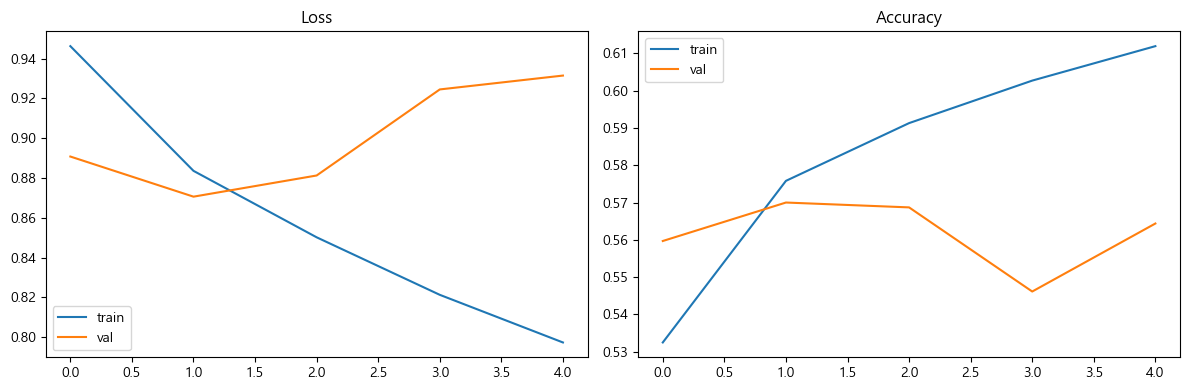

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train'); axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train'); axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. 모델 평가

In [16]:
loss, acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f'테스트 Loss: {loss:.4f}  Accuracy: {acc:.4f}')

y_pred = model.predict(X_test, batch_size=512, verbose=1).argmax(axis=1)
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=3))
print('=== Confusion Matrix (행=실제, 열=예측) ===')
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=[f'실제_{n}' for n in LABEL_NAMES],
                       columns=[f'예측_{n}' for n in LABEL_NAMES]))

테스트 Loss: 0.8707  Accuracy: 0.5721
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step

=== Classification Report ===
              precision    recall  f1-score   support

          부정      0.473     0.548     0.508      5615
          중립      0.371     0.492     0.423      4707
          긍정      0.793     0.618     0.695     11022

    accuracy                          0.572     21344
   macro avg      0.546     0.553     0.542     21344
weighted avg      0.616     0.572     0.586     21344

=== Confusion Matrix (행=실제, 열=예측) ===
       예측_부정  예측_중립  예측_긍정
실제_부정   3078   1726    811
실제_중립   1420   2318    969
실제_긍정   2006   2202   6814


## 5. 예측 함수

In [17]:
def to_sequence(text):
    cleaned = clean_text(text)
    if cleaned == '': return None
    tokens = okt.morphs(cleaned)
    encoded = tokenizer.texts_to_sequences([tokens])[0]
    return encoded if len(encoded) > 0 else None

def analyze_sentiment(text):
    seq = to_sequence(text)
    if seq is None: return '중립', 0.0
    X = pad_sequences([seq], maxlen=MAX_LEN)
    p = model.predict(X, verbose=0)[0]
    idx = int(np.argmax(p))
    return LABEL_NAMES[idx], float(p[idx])

def analyze_sentiment_batch(texts, batch_size=512):
    labels_out = [None] * len(texts)
    confs_out  = [0.0]  * len(texts)
    valid_idx, valid_seqs = [], []
    print('▶ 전처리/토큰화 중...')
    for i, t in enumerate(tqdm(texts)):
        seq = to_sequence(t)
        if seq is None:
            labels_out[i] = '중립'
        else:
            valid_idx.append(i)
            valid_seqs.append(seq)
    if not valid_seqs:
        return labels_out, confs_out
    X = pad_sequences(valid_seqs, maxlen=MAX_LEN)
    print('▶ 예측 중...')
    preds = model.predict(X, batch_size=batch_size, verbose=1)
    max_p = preds.max(axis=1); arg_p = preds.argmax(axis=1)
    for j, i in enumerate(valid_idx):
        labels_out[i] = LABEL_NAMES[arg_p[j]]
        confs_out[i]  = float(max_p[j])
    return labels_out, confs_out

for t in ['이 책 정말 재밌어요. 강추합니다',
         '그냥 그래요 시간 떼우기용',
         '돈 아깝다 노잼이네요']:
    print(f'{t}  →  {analyze_sentiment(t)}')

이 책 정말 재밌어요. 강추합니다  →  ('긍정', 0.9829110503196716)
그냥 그래요 시간 떼우기용  →  ('부정', 0.4402557611465454)
돈 아깝다 노잼이네요  →  ('중립', 0.4725012183189392)


## 6. CSV 파일별 예측 결과 저장

### 6-1. watcha_book_comments.csv (Korean — 예측만)

In [18]:
df_watcha = pd.read_csv('watcha_book_comments.csv')
print('shape:', df_watcha.shape)
labels, confs = analyze_sentiment_batch(df_watcha['comment'].fillna('').astype(str).tolist())
df_watcha['sentiment'] = labels
df_watcha['confidence'] = confs
df_watcha.to_csv('result_watcha_book_comments.csv', index=False, encoding='utf-8-sig')
print('\n✅ 저장: result_watcha_book_comments.csv')
print(df_watcha['sentiment'].value_counts())

shape: (105185, 4)
▶ 전처리/토큰화 중...


100%|██████████| 105185/105185 [11:53<00:00, 147.32it/s]


▶ 예측 중...
206/206 ━━━━━━━━━━━━━━━━━━━━ 30s 146ms/step

✅ 저장: result_watcha_book_comments.csv
sentiment
긍정    77185
중립    16467
부정    11533
Name: count, dtype: int64


### 6-2. yes24_book_reviews.csv (Korean)

In [19]:
labels, confs = analyze_sentiment_batch(df_yes24['ReviewText'].fillna('').astype(str).tolist())
df_yes24['sentiment'] = labels
df_yes24['confidence'] = confs
df_yes24.to_csv('result_yes24_book_reviews.csv', index=False, encoding='utf-8-sig')
print('\n✅ 저장: result_yes24_book_reviews.csv')
print(df_yes24['sentiment'].value_counts())
if 'ReviewRating' in df_yes24.columns:
    print('\n예측 감성별 평균 평점:')
    print(df_yes24.groupby('sentiment')['ReviewRating'].agg(['mean', 'count']).round(2))

▶ 전처리/토큰화 중...


100%|██████████| 42890/42890 [14:52<00:00, 48.03it/s] 


▶ 예측 중...
84/84 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step

✅ 저장: result_yes24_book_reviews.csv
sentiment
긍정    41549
중립      992
부정      349
Name: count, dtype: int64

예측 감성별 평균 평점:
           mean  count
sentiment             
긍정         9.49  41549
부정         3.34    349
중립         5.94    992


### 6-3. reviews.csv (English → 한국어 번역 후 예측)
전체 27만 건을 다시 번역하지 않고, 1-3에서 번역해둔 캐시(`reviews_translated_cache.csv`)를 활용.  
캐시에 없는 나머지는 영문 그대로 predict(혹은 추가 번역) — 여기서는 캐시된 분에 한해 예측.

In [20]:
# 캐시 활용: 번역된 reviews에 대해 예측
df_rev_pred = pd.read_csv('reviews_translated_cache.csv')
print(f'예측 대상(번역 캐시): {len(df_rev_pred):,}건')

labels, confs = analyze_sentiment_batch(df_rev_pred['text_ko'].fillna('').astype(str).tolist())
df_rev_pred['sentiment'] = labels
df_rev_pred['confidence'] = confs
df_rev_pred.to_csv('result_reviews.csv', index=False, encoding='utf-8-sig')
print('\n✅ 저장: result_reviews.csv')
print(df_rev_pred['sentiment'].value_counts())

# 원본 rating과 비교
if 'label' in df_rev_pred.columns:
    df_rev_pred['true_label_name'] = df_rev_pred['label'].map({i: n for i, n in enumerate(LABEL_NAMES)})
    print('\n실제 라벨 vs 예측 (rating 기준):')
    print(pd.crosstab(df_rev_pred['true_label_name'], df_rev_pred['sentiment']))

예측 대상(번역 캐시): 231,844건
▶ 전처리/토큰화 중...


100%|██████████| 231844/231844 [06:17<00:00, 613.54it/s] 


▶ 예측 중...
373/373 ━━━━━━━━━━━━━━━━━━━━ 54s 145ms/step

✅ 저장: result_reviews.csv
sentiment
중립    107150
부정     79388
긍정     45306
Name: count, dtype: int64

실제 라벨 vs 예측 (rating 기준):
sentiment           긍정     부정     중립
true_label_name                     
긍정               31463  25978  42559
부정                6729  36880  28528
중립                7114  16530  36063


## 7. 시각화 — 파일별 감성 분포

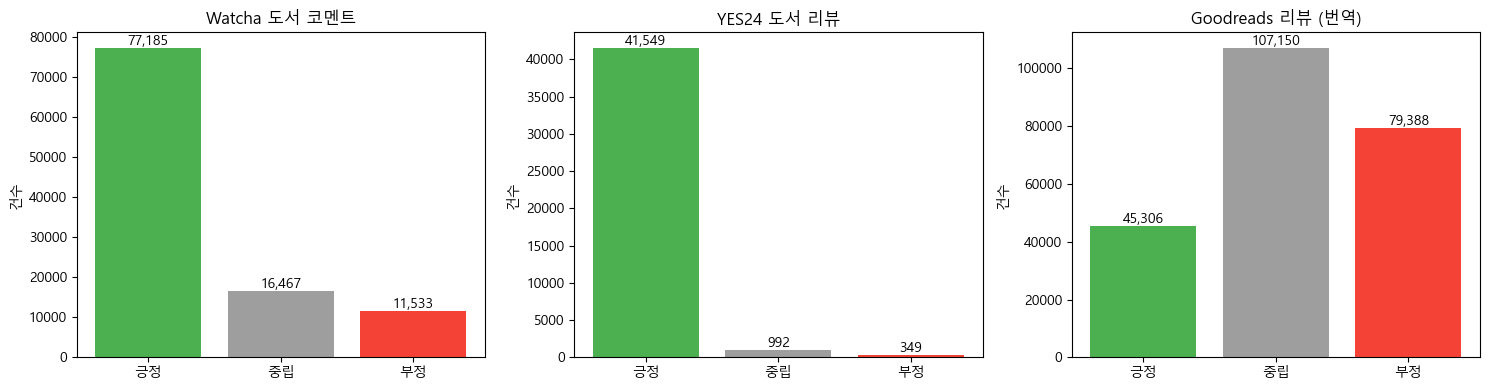

In [21]:
order = ['긍정', '중립', '부정']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [
    ('Watcha 도서 코멘트', df_watcha),
    ('YES24 도서 리뷰',    df_yes24),
    ('Goodreads 리뷰 (번역)', df_rev_pred),
]):
    counts = df['sentiment'].value_counts().reindex(order).fillna(0)
    ax.bar(counts.index, counts.values, color=['#4CAF50', '#9E9E9E', '#F44336'])
    ax.set_title(name); ax.set_ylabel('건수')
    for i, v in enumerate(counts.values):
        ax.text(i, v, f'{int(v):,}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 8. 모델 / 토크나이저 저장

In [22]:
model.save('./model_3class/sa_3class_model.keras')
joblib.dump(tokenizer, './model_3class/sa_3class_tokenizer.pkl')
joblib.dump({'MAX_LEN': MAX_LEN, 'LABEL_NAMES': LABEL_NAMES, 'NUM_WORDS': NUM_WORDS},
            './model_3class/sa_3class_config.pkl')
print('✅ 모델/토크나이저/설정 저장 완료 → ./model_3class/')

✅ 모델/토크나이저/설정 저장 완료 → ./model_3class/


## 참고 사항
- **번역 시간**: Helsinki NMT GPU에서 30만 건 ≈ 1~2시간, CPU에선 매우 느림 (10시간 이상).
  실제 운영 환경 GPU 있다면 `MAX_PER_CLASS = 100000` 그대로, 없다면 5000~10000으로 줄여 테스트 권장.
- 번역 결과는 `reviews_translated_cache.csv`로 저장되므로 다음 실행 시 1-3 셀을 건너뛰고  
  `df_reviews_sample = pd.read_csv('reviews_translated_cache.csv')` 로 시작해도 됩니다.
- 형태소 분석 결과는 `train_tokenized_cache.csv`로 저장되므로 재학습 시 토큰화 단계도 건너뛸 수 있습니다.